# Exploration de données: analyse détaillée par magasin 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Chargement des données
sales       = pd.read_csv('/Users/maelys_thr/Desktop/sales_train_evaluation.csv')
calendar    = pd.read_csv('/Users/maelys_thr/Desktop/calendar.csv')
sell_prices = pd.read_csv('/Users/maelys_thr/Desktop/sell_prices.csv')

# Préparation des dates et colonnes de ventes
calendar["date"] = pd.to_datetime(calendar["date"])
day_cols         = [c for c in sales.columns if c.startswith('d_')]
day_to_date      = dict(zip(calendar['d'], calendar['date']))

## Première lecture du fichier

### Dimension

In [3]:
print(sales.shape)

(30490, 1947)


En effet, notre dataset issu de la compétition M5 forecasting Kaggle contient 30 490 produits, répartis en plusieurs catégories ( FOOD, HOBBIES, HOUSEHOLDS) dans 10 magasins au sein de 3 états aux USA: [CA_1, CA_2, CA_3, TX_1, TX_2, TX_3, WI_1, WI_2, WI_3]. On constate les 1 947 colonnes contenant 6 colonnes descriptives (id, item_id, dept_id, cat_id, store_id, state_id) ainsi 1 941 jours de ventes (de 2011 à 2016).
C'est une partie que vous avez probablement déjà vu lors de l'exploration de données globale faite par Lisa mais on le rappelle ici afin de reprendre les bases correctement et ne pas se perdre. 

### Informations sur le dataset

In [4]:
print(sales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), object(6)
memory usage: 452.9+ MB
None


### Valeurs manquantes

In [5]:
print(sales.isnull().sum())

id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
           ..
d_1937      0
d_1938      0
d_1939      0
d_1940      0
d_1941      0
Length: 1947, dtype: int64


In [6]:
# Pourcentage de zéros dans les ventes 
print(f"Pourcentage de zéros : {(sales[day_cols] == 0).mean().mean()*100:.1f}%")

Pourcentage de zéros : 68.0%


En effet, les données ne contiennent aucune valeur manquante. Cependant, environ 68 % des valeurs de ventes sont nulles, ce qui met en évidence un phénomène de demande intermittente : de nombreux produits ne sont pas vendus quotidiennement. Cette caractéristique du dataset devra être prise en compte dans le choix des méthodes de modélisation et de prévision.

### Statistiques de base

In [11]:
print(sales.describe())

                d_1           d_2           d_3           d_4           d_5  \
count  30490.000000  30490.000000  30490.000000  30490.000000  30490.000000   
mean       1.070220      1.041292      0.780026      0.833454      0.627944   
std        5.126689      5.365468      3.667454      4.415141      3.379344   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      0.000000      0.000000      0.000000      0.000000   
50%        0.000000      0.000000      0.000000      0.000000      0.000000   
75%        0.000000      0.000000      0.000000      0.000000      0.000000   
max      360.000000    436.000000    207.000000    323.000000    296.000000   

                d_6           d_7           d_8           d_9          d_10  \
count  30490.000000  30490.000000  30490.000000  30490.000000  30490.000000   
mean       0.958052      0.918662      1.244080      1.073663      0.838701   
std        4.785947      5.059495      6.617729    

Les statistiques descriptives montrent bien qu’une grande partie de ces ventes est égale à 0․ En effet‚ durant de nombreux jours‚ les quartiles et la médiane sont nuls‚ ce qui confirme une demande intermittente : beaucoup de produits ne sont pas vendus quotidiennement․
On observe également que les ventes moyennes restent faibles․ Malgré cela‚ certaines valeurs maximales sont très élevées․ Cela montre que les ventes varient fortement selon les produits․ Suivant les périodes‚ elles varient aussi․
Cette caractéristique devra être prise en considération lors du choix du modèle de prévision․

## 2. Évolution temporelle des centes par magasin 
L'objectif de cette visualisation est d'analyser l'évolution temporelle des ventes totales dans chacun des 10 magasins. En regroupant par magasin, on peut comparer les dynamiques de vente entre les différents points de vente et identifier d’éventuelles différences de comportement.

Le lissage sur 7 jours a quant à lui pour but d'atténuer les variations quotidiennes, souvent dues au bruit ou à des fluctuations ponctuelles, afin de mettre en évidence les tendances générales. Cette visualisation permet donc d’identifier les moments où les ventes augmentent ou baissent, les éventuels effets saisonniers, mais aussi les magasins dont le comportement est particulier.

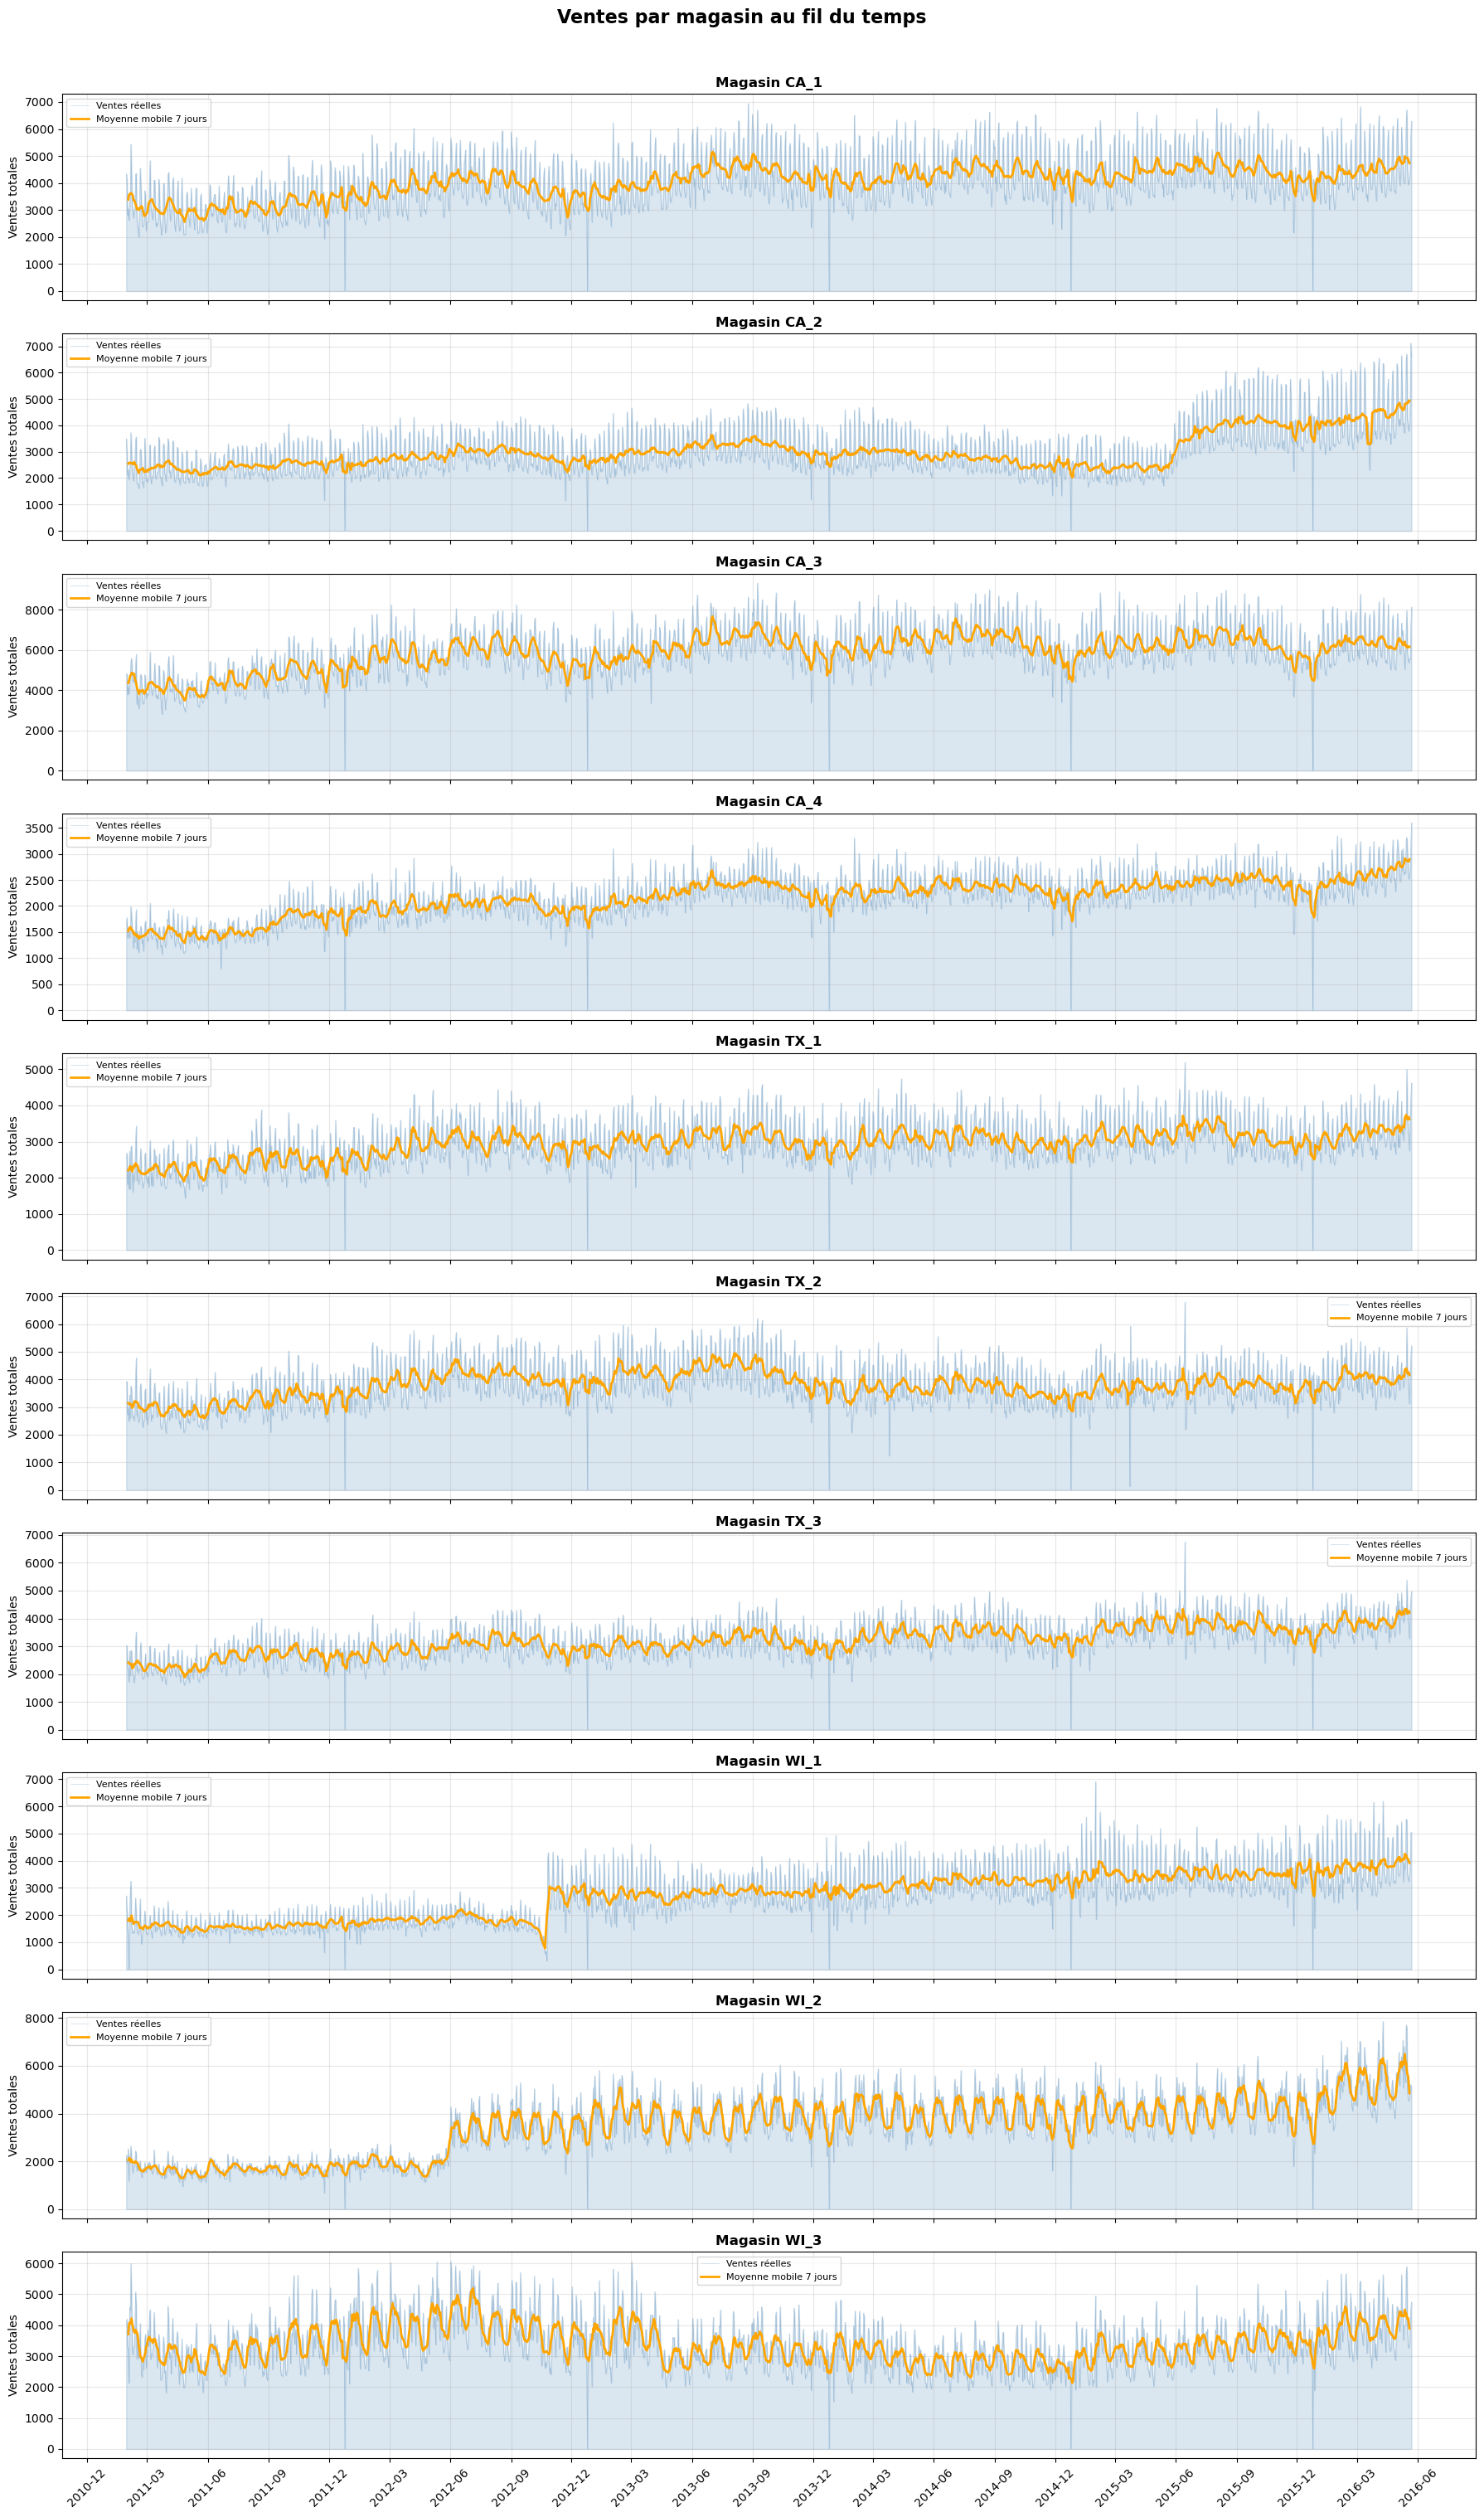

In [14]:
import matplotlib.dates as mdates

sales_by_store = sales.groupby('store_id')[day_cols].sum()
stores = sales_by_store.index.tolist()
dates = [day_to_date[d] for d in day_cols if d in day_to_date]

fig, axes = plt.subplots(len(stores), 1, figsize=(18, len(stores)*3), sharex=True)

for i, store in enumerate(stores):
    ax = axes[i]
    y_raw = sales_by_store.loc[store].values[:len(dates)]
    y_smooth = pd.Series(y_raw).rolling(window=7, center=True).mean()

    ax.fill_between(dates, y_raw, alpha=0.2, color='steelblue')

    ax.plot(dates, y_raw,
            color='steelblue',
            alpha=0.3,
            linewidth=0.5,
            label='Ventes réelles')

    ax.plot(dates, y_smooth,
            color='orange',
            linewidth=2,
            label='Moyenne mobile 7 jours')

    ax.set_title(f'Magasin {store}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Ventes totales')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.suptitle('Ventes par magasin au fil du temps',
             fontsize=16,
             fontweight='bold',
             y=1.01)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
mean_sales_store = sales.groupby('store_id')[day_cols].sum().mean(axis=1)
mean_sales_store = mean_sales_store.sort_values(ascending=False)
print(mean_sales_store)

store_id
CA_3    5854.477074
CA_1    4035.161257
TX_2    3776.219474
WI_2    3450.792375
WI_3    3370.714580
TX_3    3197.290057
CA_2    2997.627512
TX_1    2932.933024
WI_1    2710.719217
CA_4    2154.834621
dtype: float64


## Résumé: 

On constate que les graphes témoignent de comportements très hétérogènes entre les magasins.
Prenons état par état: 

**Californie** : CA_3 domine largement avec une moyenne d’environ 5854 ventes par jour et des volumes pouvant atteindre plus de 8000 ventes lors de certains pics. À l’inverse, CA_4 est le magasin le moins actif avec environ 2155 ventes quotidiennes. CA_1 présente une évolution relativement régulière et stable sur l’ensemble de la période. CA_2 reste stable jusqu’en 2015 puis connaît une forte hausse des ventes. Néanmoins, on ne peut pas expliquer l'origine uniquement à partir des données disponibles.

**Texas** : TX_2 est le magasin le plus performant avec une moyenne proche de 3776 ventes par jour et des volumes généralement compris entre 3000 et 5000 ventes. TX_1 et TX_3 présentent des comportements plus proches et relativement stables autour de 2500 à 3500 ventes.

**Wisconsin** : Le phénomène le plus marquant concerne WI_1 et WI_2, qui connaissent une augmentation brutale des ventes vers mi-2012. Les ventes moyennes de WI_1 passent d’environ 1500 à 3000, tandis que celles de WI_2 passent d’environ 2000 à 4000. En revanche, WI_3 reste relativement stable sur toute la période malgré son appartenance au même état. Cela montre que les disparités observées dépendent davantage des magasins eux-mêmes que de l’état auquel ils appartiennent.

## 3. Heatmap des ventes totales par magasin et par année

Les courbes précédentes nous ont permis de visualiser la dynamique temporelle détaillée de chaque magasin. Cependant comparer 10 magasins simultanément reste "lourd" à vu d'oeil. On utilise donc une heatmap qui permet de voir les volumes annuels de tous les magasins en une seule fois grâce au code couleur, et d'avoir les chiffres exacts. 
Note : les données 2016 ne couvrent que janvier à juin, elles sont donc moins élevées que les autres années mais restent incluses pour montrer la tendance en cours.

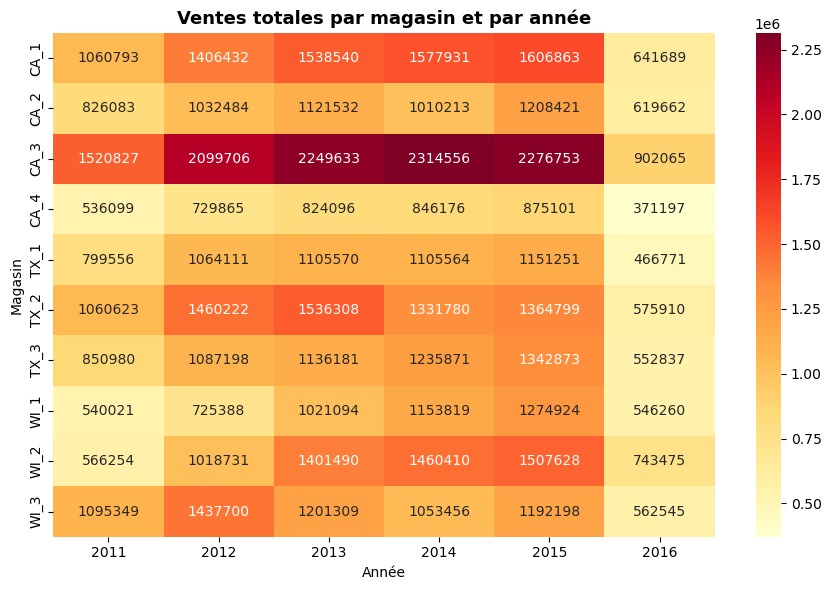

In [20]:
# On récupère l'année pour chaque jour
calendar['year'] = calendar['date'].dt.year
year_day = calendar[['d', 'year']].set_index('d')

# Dictionnaire qui va contenir les ventes annuelles par magasin
heatmap_data = {}
for store in sorted(sales['store_id'].unique()):
    store_sales = sales[sales['store_id'] == store][day_cols].sum()
    yearly = {}   # Dictionnaire des ventes par année
    for year in [2011, 2012, 2013, 2014, 2015, 2016]:
        days = [d for d in year_day[year_day['year'] == year].index if d in store_sales.index]
        yearly[year] = store_sales[days].sum()
    heatmap_data[store] = yearly

df_heatmap = pd.DataFrame(heatmap_data).T

plt.figure(figsize=(9, 6))
sns.heatmap(df_heatmap, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Ventes totales par magasin et par année', fontsize=13, fontweight='bold')
plt.xlabel('Année')
plt.ylabel('Magasin')
plt.tight_layout()
plt.show()

**Interprétation :**

La heatmap confirme les différences importantes observées précédemment entre les magasins. CA_3 reste le magasin le plus performant sur l’ensemble de la période, tandis que CA_4 et WI_1 affichent des volumes de ventes plus faibles.
On retrouve également une tendance générale à la hausse entre 2011 et 2015 pour la majorité des magasins, avec une progression particulièrement marquée pour WI_2. À l’inverse, certains magasins comme CA_2 ou TX_1 évoluent de façon plus modérée.
Cette visualisation confirme donc que les comportements de vente varient fortement d’un magasin à l’autre. On en déduit ici que les variables store_id et state_id auront sûrement une importance élevée lors de notre modélisation mais on confirmera cela au fur et à mesure de notre analyse. 

## 4. Top 10 des produits les plus vendus par magasin

On identifie les produits phares de chaque magasin afin d'orienter les décisions de réapprovisionnement pour Sophie Martin. On affiche d'abord tous les magasins puis on sélectionne un représentant par état (CA_3, TX_2, WI_2) car ce sont les magasins aux volumes les plus significatifs et que cela nous permet d'affiner notre analyse car sinon il y a trop d'informations (comme vous pourrez le voir ci-dessous) et que notre but est de retenir l'essentiel

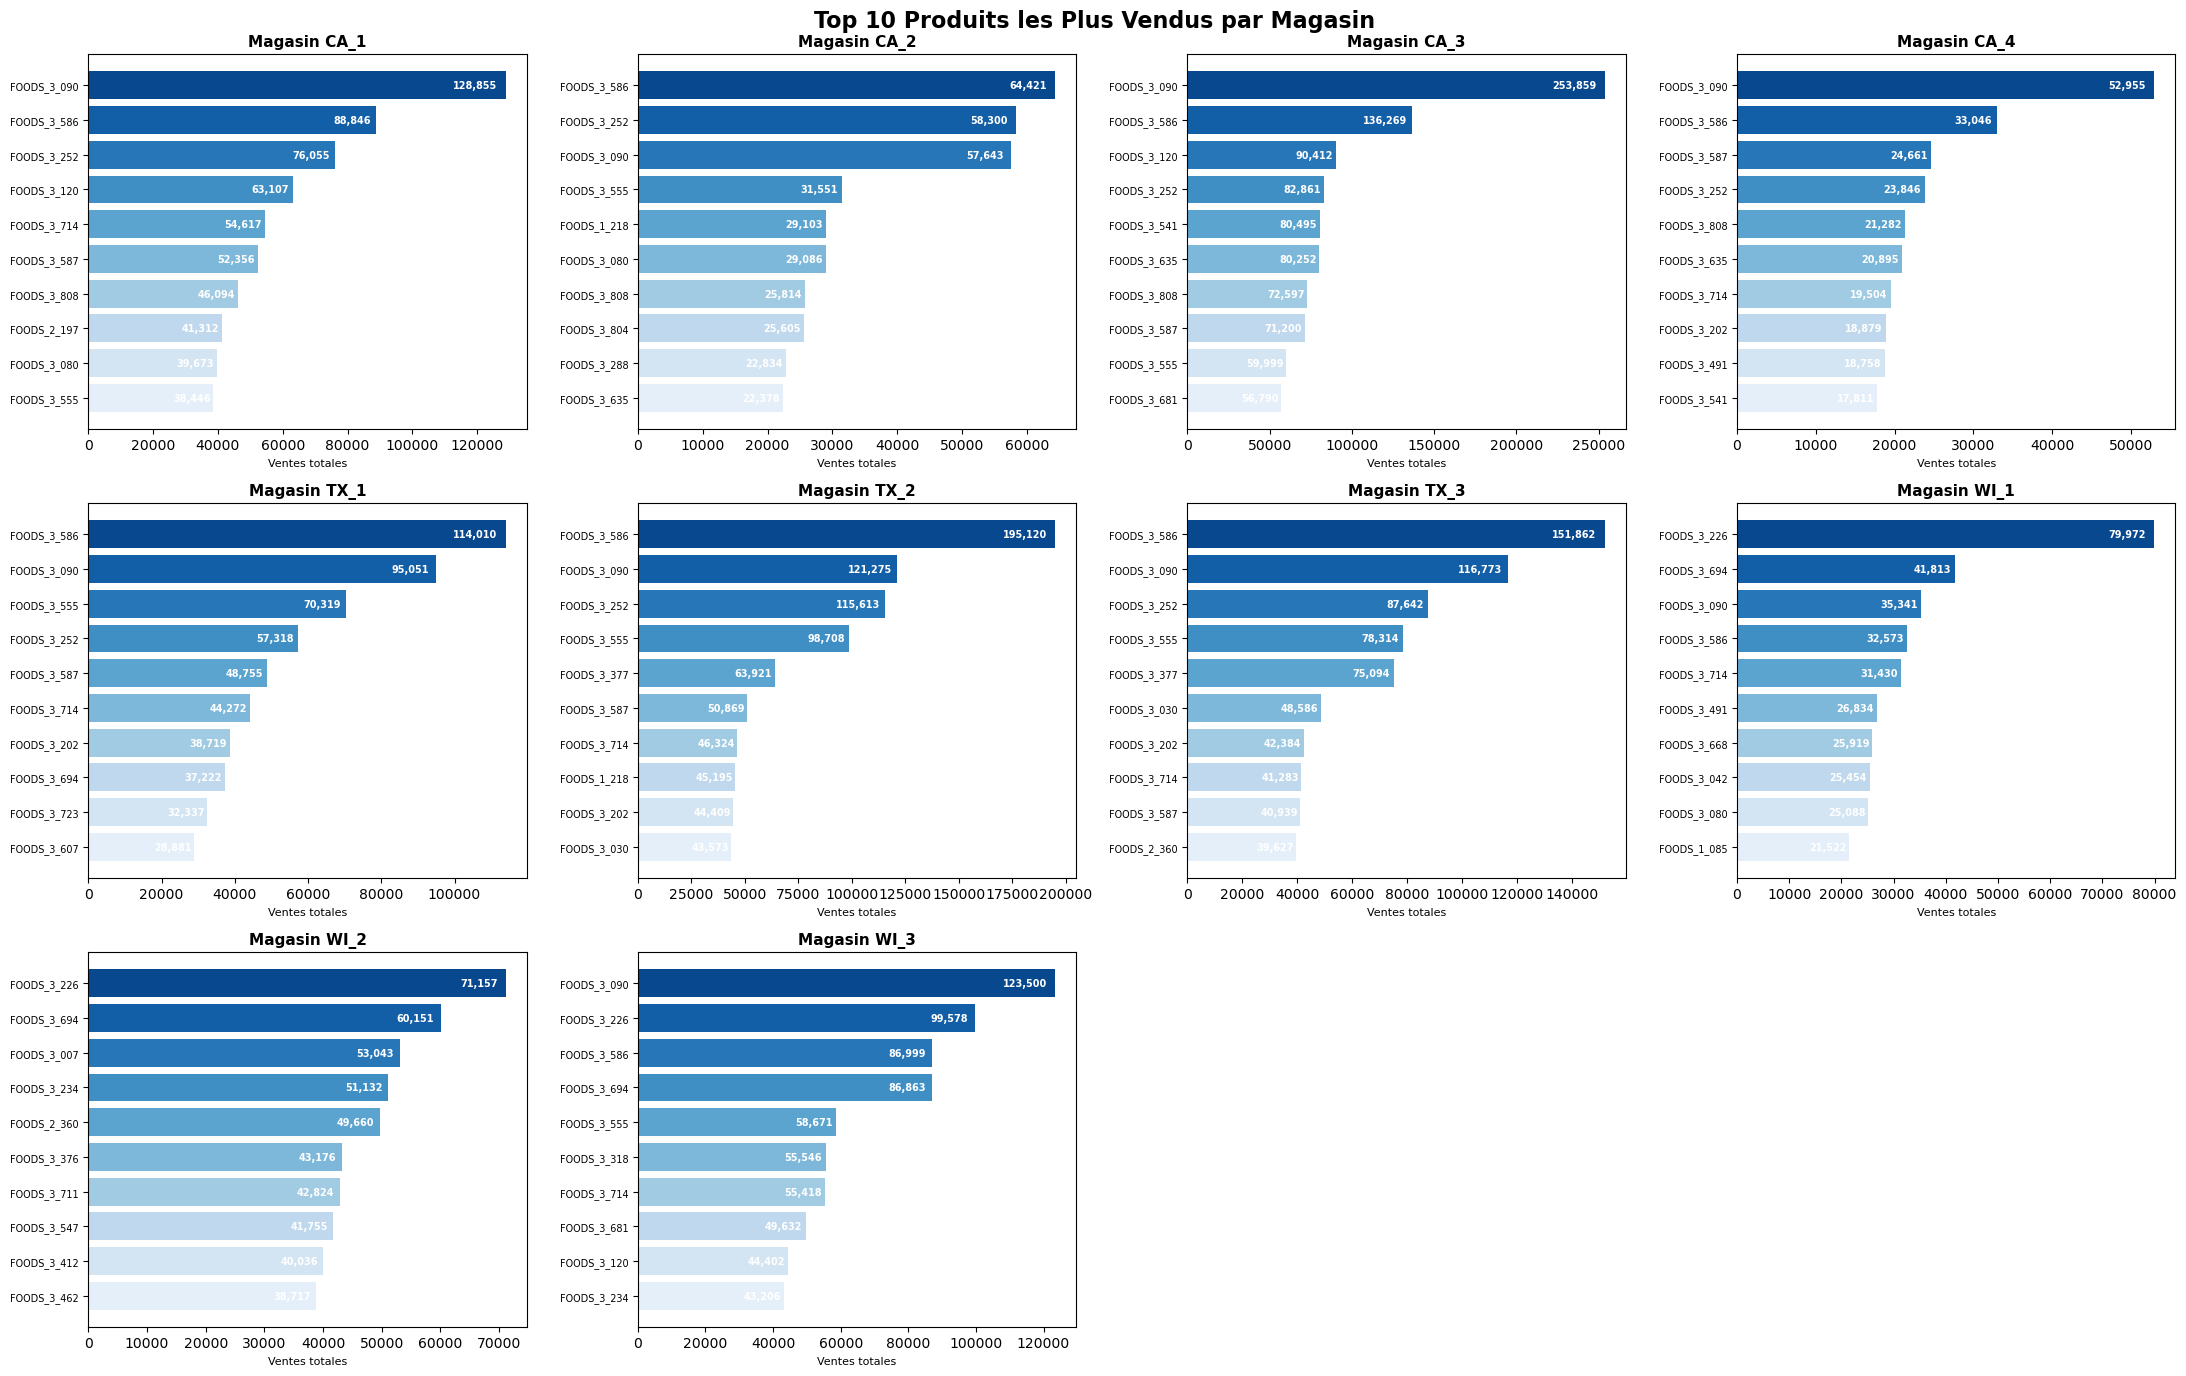

In [18]:
sales['total_sales'] = sales[day_cols].sum(axis=1)

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
axes = axes.flatten()

stores = sorted(sales['store_id'].unique())

for i, store in enumerate(stores):
    ax = axes[i]
    store_data = sales[sales['store_id'] == store]
    top10 = store_data.nlargest(10, 'total_sales')[['item_id', 'total_sales']]
    
    colors = sns.color_palette("Blues_r", 10)
    bars = ax.barh(top10['item_id'], top10['total_sales'], color=colors)
    
    for bar, val in zip(bars, top10['total_sales']):
        ax.text(bar.get_width() * 0.98, bar.get_y() + bar.get_height()/2,
                f'{int(val):,}', va='center', ha='right', fontsize=7, 
                color='white', fontweight='bold')
    
    ax.set_title(f'Magasin {store}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Ventes totales', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.invert_yaxis()

for j in range(len(stores), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 10 Produits les Plus Vendus par Magasin', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

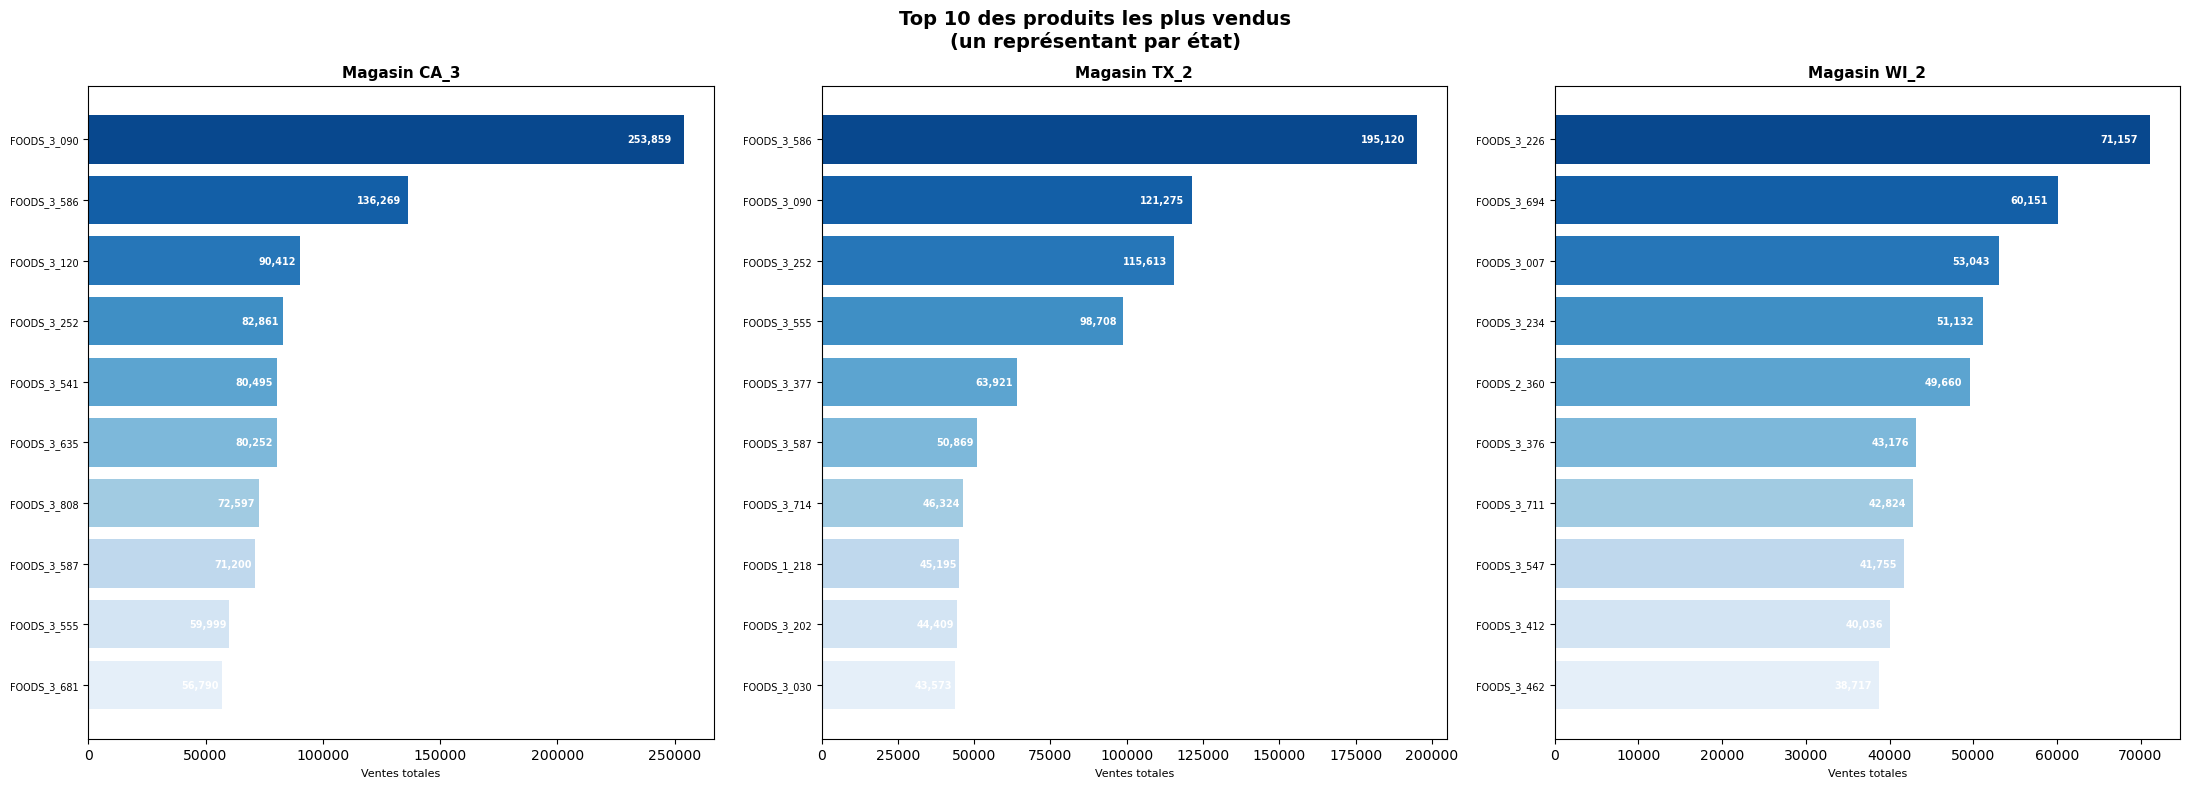

In [19]:
representants = ['CA_3', 'TX_2', 'WI_2']

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

for i, store in enumerate(representants):
    ax = axes[i]
    store_data = sales[sales['store_id'] == store]
    top10 = store_data.nlargest(10, 'total_sales')[['item_id', 'total_sales']]
    
    colors = sns.color_palette("Blues_r", 10)
    bars = ax.barh(top10['item_id'], top10['total_sales'], color=colors)
    
    for bar, val in zip(bars, top10['total_sales']):
        ax.text(bar.get_width() * 0.98, bar.get_y() + bar.get_height()/2,
                f'{int(val):,}', va='center', ha='right', fontsize=7,
                color='white', fontweight='bold')
    
    ax.set_title(f'Magasin {store}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Ventes totales', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.invert_yaxis()

plt.suptitle('Top 10 des produits les plus vendus\n(un représentant par état)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Ce que l'on constate est que les volumes diffèrent entre les 3 magasins ( 250k environ pour CA_3 contre environ 70k pour WI_2) et la catégorie du produit leader est la même pour les 3 magasins ( à savoir FOOD_3). Cependant, le produit leader n'est pas le même. 
Par conséquent, ces variations locales témoignent d’une information importante pour la
modélisation : bien que les tendances globales soient similaires, les priorités
d'approvisionnement diffèrent selon la localisation. Ce qui confirme que la dimension géographique est essentielle à prendre en compte pour avoir un modèle de prévision performant.


## 5. Comparaison des ventes entre états

Les disparités observées entre magasins soulèvent une question : ces écarts sont-ils propres à chaque magasin ou reflètent-ils des disparités plus larges à l'échelle des états ? On sépare ici les ventes par état sur l'ensemble de la période.

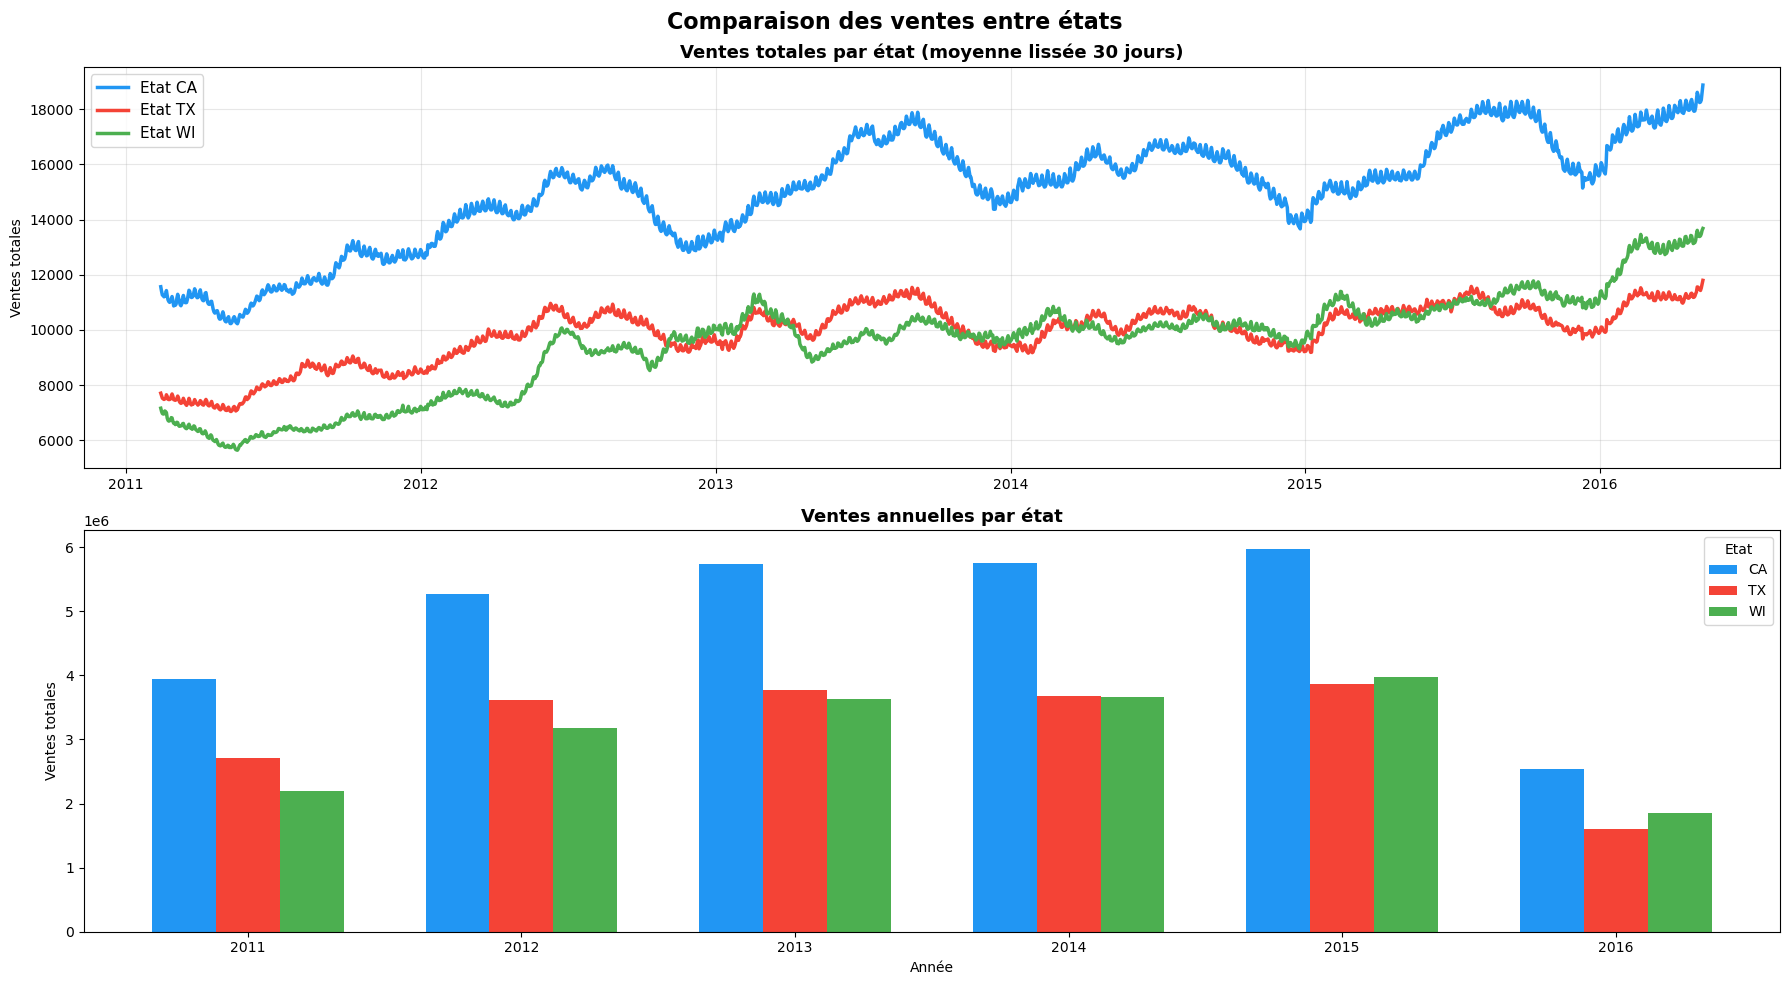

In [21]:
sales_by_state = sales.groupby('state_id')[day_cols].sum()
dates = [day_to_date[d] for d in day_cols if d in day_to_date]

colors_state = {'CA': '#2196F3', 'TX': '#F44336', 'WI': '#4CAF50'}

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Graphe 1 : séries temporelles lissées sur 30 jours
for state in sales_by_state.index:
    y = sales_by_state.loc[state].values[:len(dates)]
    y_smooth = pd.Series(y).rolling(30, center=True).mean()
    axes[0].plot(dates, y_smooth, linewidth=2.5, 
                 label=f'Etat {state}', color=colors_state.get(state))

axes[0].set_title('Ventes totales par état (moyenne lissée 30 jours)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Ventes totales')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Graphe 2 : ventes annuelles par état
calendar['year'] = calendar['date'].dt.year
year_day = calendar[['d', 'year']].set_index('d')

state_year = {}
for state in sales_by_state.index:
    row = sales_by_state.loc[state]
    yearly = {}
    for year in [2011, 2012, 2013, 2014, 2015, 2016]:
        days = [d for d in year_day[year_day['year'] == year].index if d in row.index]
        yearly[year] = row[days].sum()
    state_year[state] = yearly

df_year = pd.DataFrame(state_year).T
df_year.T.plot(kind='bar', ax=axes[1], 
               color=[colors_state.get(s) for s in df_year.index], width=0.7)

axes[1].set_title('Ventes annuelles par état', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Ventes totales')
axes[1].set_xlabel('Année')
axes[1].legend(title='Etat', fontsize=10)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=0)

plt.suptitle('Comparaison des ventes entre états', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
moyenne_par_etat = sales_by_state.mean(axis=1)
print(moyenne_par_etat)

state_id
CA    15042.100464
TX     9906.442555
WI     9532.226172
dtype: float64


**Interprétation :**

La Californie domine sur toute la période avec en moyenne 15 042 ventes par jour contre 9 906 pour le Texas et 9 532 pour le Wisconsin. Cette domination confirme que les écarts observés entre CA_3 et les autres magasins ne sont pas propres à ces magasins, ils reflètent une dynamique géographique plus importante.

Malgré le fait que le Texas et le Wisconsin montrent des volumes similaires, ils restent bien en dessous de la Californie. On note tout de même une progression du Wisconsin qui rattrape progressivement le Texas en fin de période, aussi bien à l'échelle journalière qu'annuelle ce qui est cohérent avec le basculement de WI_1 et WI_2 observé précédemment ( 1er graphe)

Globalement, les trois états suivent la même dynamique temporelle : les pics et creux apparaissent simultanément, ce qui suggère que certains facteurs externes communs influencent la demande de manière uniforme à l'échelle nationale. Ces facteurs pourraient être les événements du calendrier ce que nous analyserons dans les prochaines sections, et plus en détail encore dans un autre notebook, notamment pour la partie recherche opérationnelle. 

## 6. Corrélation entre magasins

Les analyses précédentes ont mis en évidence des disparités importantes entre magasins en termes de volumes et de dynamique temporelle. On cherche maintenant à mesurer à quel point les magasins évoluent de façon similaire dans le temps.

Une forte corrélation suggère des facteurs communs dont nous avons abordé la présence ci-dessus. Une faible corrélation indique des dynamiques locales propres à chaque magasin.

On utilise deux niveaux de lecture complémentaires : une heatmap pour comparer toutes les paires en un seul coup d'œil, puis des scatter plots pour visualiser concrètement la qualité de la corrélation.

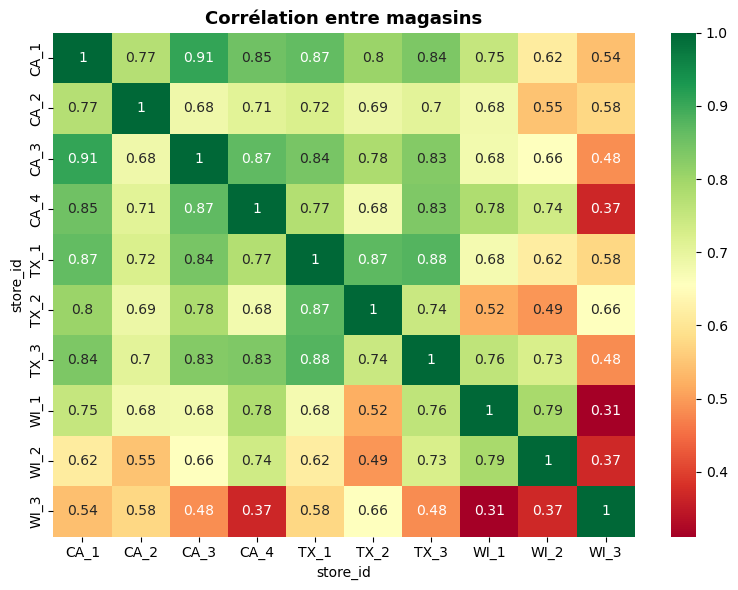

In [22]:
sales_by_store_daily = sales.groupby('store_id')[day_cols].sum().T
sales_by_store_daily.index = [day_to_date.get(d) for d in sales_by_store_daily.index]
sales_by_store_daily = sales_by_store_daily.dropna()

# Matrice de corrélation 
corr_matrix = sales_by_store_daily.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn')
plt.title('Corrélation entre magasins', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interprétation :**

Tous les magasins sont positivement corrélés entre eux avec des valeurs allant d’environ 0.31 à 0.91. Les corrélations les plus fortes s’observent généralement entre certains magasins présentant des comportements de vente similaires, comme CA_1 et CA_3 (0.91) ou TX_1 et TX_3 (0.88).
Cependant, cette tendance n’est pas systématique. Par exemple, WI_1 et WI_3 n’affichent qu’une corrélation de 0.31, ce qui montre que l’appartenance à un même état ne suffit pas à expliquer certaines similarités de comportement. 

Ces résultats confirment donc que les magasins ne sont ni totalement indépendants ni parfaitement synchronisés. Le modèle devra donc prendre en compte à la fois les tendances globales et les spécificités propres à chaque magasin.

### Scatter plots intra-état
On compare les magasins appartenant à un même état afin d’évaluer si la proximité géographique suffit à expliquer les similarités observées dans les comportements de vente.

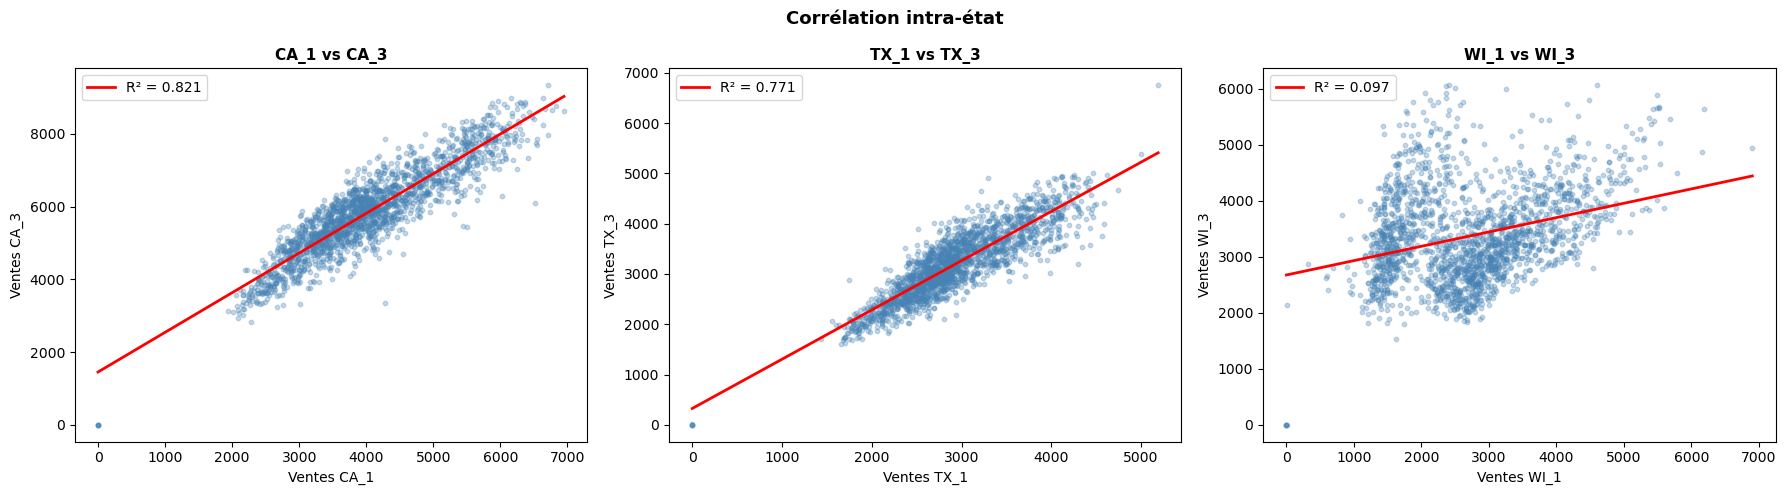

In [23]:
from scipy import stats

paires_intra = [('CA_1', 'CA_3'), ('TX_1', 'TX_3'), ('WI_1', 'WI_3')]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (s1, s2) in enumerate(paires_intra):
    axes[i].scatter(sales_by_store_daily[s1], sales_by_store_daily[s2],
                    alpha=0.3, color='steelblue', s=10)
    slope, intercept, r, p, _ = stats.linregress(sales_by_store_daily[s1],
                                                  sales_by_store_daily[s2])
    x_line = np.linspace(sales_by_store_daily[s1].min(),
                         sales_by_store_daily[s1].max(), 100)
    axes[i].plot(x_line, slope * x_line + intercept, color='red',
                 linewidth=2, label=f'R² = {r**2:.3f}')
    axes[i].set_xlabel(f'Ventes {s1}', fontsize=10)
    axes[i].set_ylabel(f'Ventes {s2}', fontsize=10)
    axes[i].set_title(f'{s1} vs {s2}', fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=10)

plt.suptitle('Corrélation intra-état', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Scatter plots inter-états
On compare des magasins situés dans des états différents afin d’étudier si des comportements de vente similaires peuvent exister indépendamment de la localisation géographique.

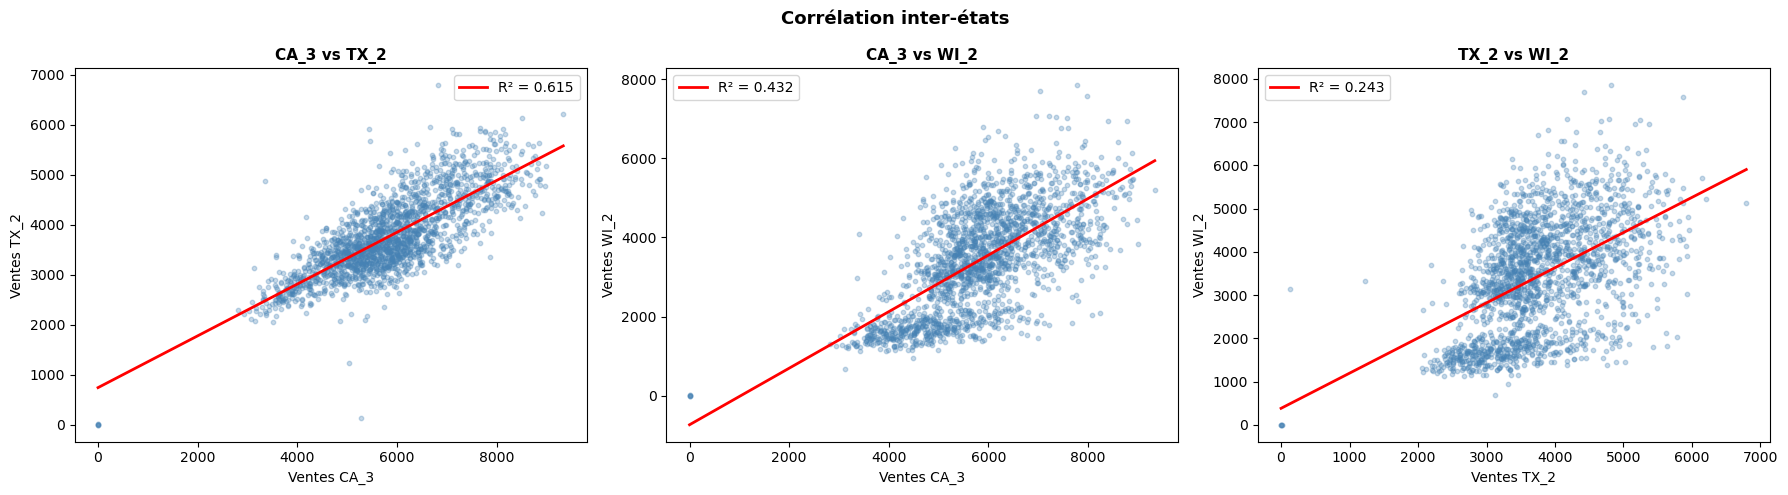

In [29]:
paires_inter = [('CA_3', 'TX_2'), ('CA_3', 'WI_2'), ('TX_2', 'WI_2')]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (s1, s2) in enumerate(paires_inter):
    axes[i].scatter(sales_by_store_daily[s1], sales_by_store_daily[s2],
                    alpha=0.3, color='steelblue', s=10)
    slope, intercept, r, p, _ = stats.linregress(sales_by_store_daily[s1],
                                                  sales_by_store_daily[s2])
    x_line = np.linspace(sales_by_store_daily[s1].min(),
                         sales_by_store_daily[s1].max(), 100)
    axes[i].plot(x_line, slope * x_line + intercept, color='red',
                 linewidth=2, label=f'R² = {r**2:.3f}')
    axes[i].set_xlabel(f'Ventes {s1}', fontsize=10)
    axes[i].set_ylabel(f'Ventes {s2}', fontsize=10)
    axes[i].set_title(f'{s1} vs {s2}', fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=10)

plt.suptitle('Corrélation inter-états', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Les scatter plots nous montrent des comportements divergents entre les magasins. 
D'un point de vue de l'intra-état, CA_1 vs CA_3 et TX_1 vs TX_3 présentent des nuages de points relativement alignés autour de la droite de régression, témoignant d'une forte corrélation entre les ventes de ces magasins malgré quelques valeurs spéciales. 
Cependant, le cas qui retient le plus l'attention est celui de WI_1 vs WI_3 avec un R^2 = 0.097. 
Les points sont dispersés et la relation linéaire apparaît très faible, ce qui montre que deux magasins appartenant au même état peuvent présenter des comportements de vente très différents (ce qui n'est pas négligeable à relever). 

De l'autre côté, en inter-états, CA_3 vs TX_2 présente au contraire une corrélation relativement forte (R^2 = 0.615) malgré le fait d'avoir des états différents, plus élevée que certaines corrélations observées au sein d’un même état. Cela suggère que les similarités de comportement ne dépendent pas uniquement de la localisation géographique.

Le graphique CA_3 vs WI_2 fait apparaître deux groupes distincts de points, probablement liés à la forte évolution des ventes observée pour WI_2 au cours de la période. 

Enfin, TX_2 vs WI_2 (R^2 = 0.243) confirme une relation beaucoup plus faible entre ces deux magasins.
Ces observations renforcent l’idée que la modélisation devra principalement être réalisée au niveau du magasin plutôt qu’au niveau de l’état.
Note pour moi-même : j'ai choisi les représentants parmi les magasins présentant les volumes de ventes les plus significatifs dans chaque état. D’autres combinaisons auraient pu conduire à des résultats différents. Par exemple, WI_1 vs WI_2 présente une corrélation nettement plus élevée.

## Piste d'amélioration suite au mi-projet - Impact du prix sur les ventes par magasin

Suite au rapport de mi-projet, nous avons identifié que l'analyse du prix pourrait enrichir notre compréhension des variations de ventes par magasin. On analyse ici si les variations de prix influencent les volumes vendus sur les produits les plus vendus par magasin.

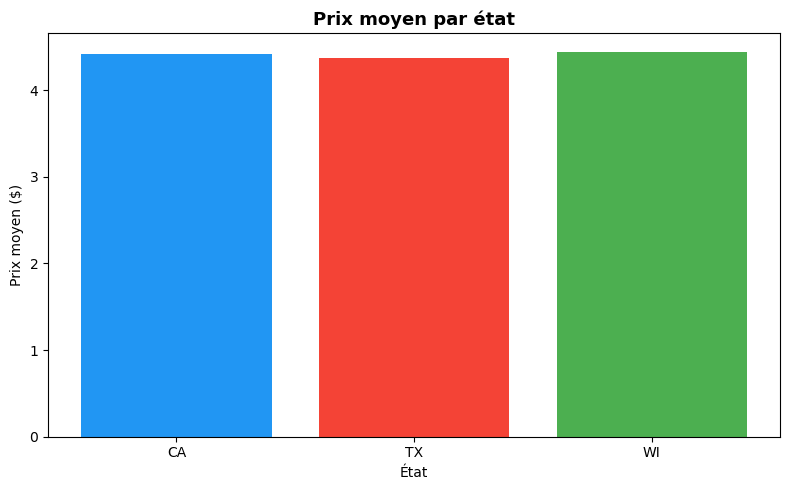

state
CA    4.417385
TX    4.376233
WI    4.439182
Name: sell_price, dtype: float64


In [30]:
prix_moyen_etat = sell_prices.groupby('store_id')['sell_price'].mean().reset_index()
prix_moyen_etat['state'] = prix_moyen_etat['store_id'].str[:2]
prix_moyen_state = prix_moyen_etat.groupby('state')['sell_price'].mean()

plt.figure(figsize=(8, 5))
plt.bar(prix_moyen_state.index, prix_moyen_state.values, color=['#2196F3', '#F44336', '#4CAF50'])
plt.title('Prix moyen par état', fontsize=13, fontweight='bold')
plt.ylabel('Prix moyen ($)')
plt.xlabel('État')
plt.tight_layout()
plt.show()

print(prix_moyen_state)

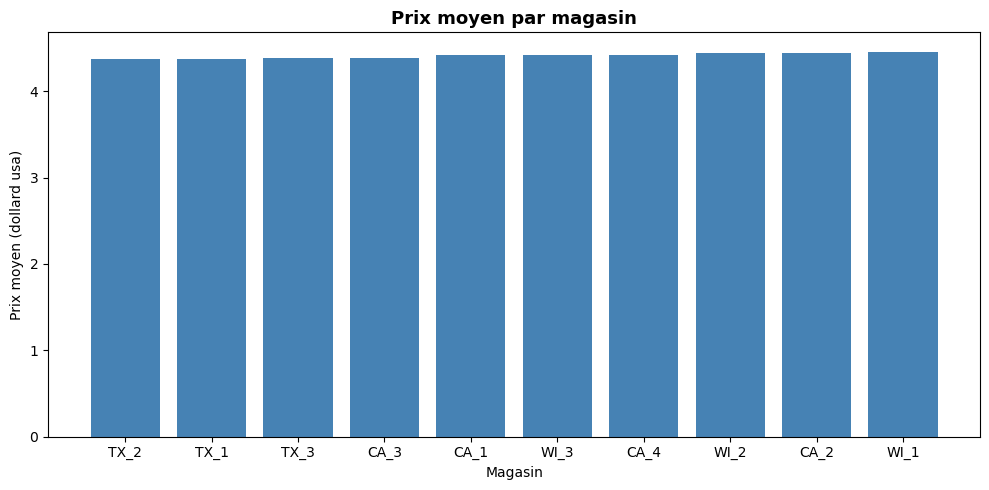

store_id
TX_2    4.366766
TX_1    4.374569
TX_3    4.387365
CA_3    4.388229
CA_1    4.414233
WI_3    4.418117
CA_4    4.421580
WI_2    4.441717
CA_2    4.445500
WI_1    4.457712
Name: sell_price, dtype: float64


In [34]:
prix_moyen_magasin = sell_prices.groupby('store_id')['sell_price'].mean().sort_values()

plt.figure(figsize=(10, 5))
plt.bar(prix_moyen_magasin.index, prix_moyen_magasin.values, color='steelblue')
plt.title('Prix moyen par magasin', fontsize=13, fontweight='bold')
plt.ylabel('Prix moyen (dollard usa)')
plt.xlabel('Magasin')
plt.tight_layout()
plt.show()

print(prix_moyen_magasin)

Cette analyse montre que les prix moyens sont quasi identiques entre tous les magasins et tous les états, avec des valeurs comprises entre 4.37 et 4.46 dollards. Walmart applique donc une politique de prix uniforme. 

Cependant cette analyse reste limitée car elle agrège tous les produits sans distinction de catégorie. Une analyse plus fine nécessiterait de comparer les prix produit par produit ce qui dépasse notre section et relève davantage de l'analyse par produit faite par Marie-noëlle. 